In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Python_ML_projects\Zomato_Project\Zomato data .csv")
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


### Convert the data type of column rate

In [3]:
def handlerate(value):
    value = str(value).split("/")
    value = value[0]
    return float(value)

df["rate"] = df["rate"].apply(handlerate)

In [4]:
df.head(3)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet


In [10]:
df["rate"].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# 1. What type of restaurant do the majority of customers order from?

In [12]:
df.head(1)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet


In [15]:
df["listed_in(type)"].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

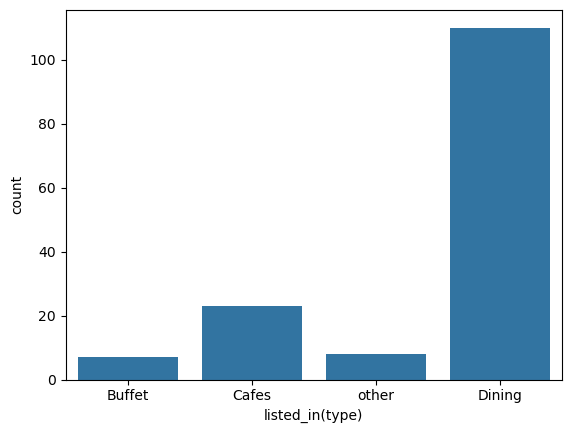

In [17]:
sns.countplot(data=df,x="listed_in(type)")
plt.show()

# 2.How many votes has each type of restaurant received from customers?

In [18]:
df.head(1)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet


In [34]:
gropued_data = df.groupby("listed_in(type)")["votes"].sum()

In [35]:
gropued_data

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

In [36]:
result = pd.DataFrame({"votes":gropued_data})

In [37]:
result

,votes
listed_in(type),
Buffet,3028
Cafes,6434
Dining,20363
other,9367


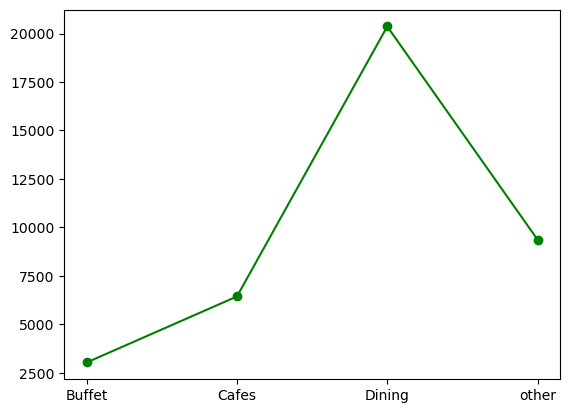

In [39]:
plt.plot(result,c="green",marker="o")

# 3. What are the ratings that the majority of restaurants have received?

In [54]:
df["rate"].value_counts()

rate
3.8    20
3.7    15
3.3    14
3.4    12
4.1    11
3.6    11
4.0    10
3.9    10
4.2     8
3.1     7
3.2     7
2.9     7
3.5     6
4.6     2
2.8     2
4.4     2
3.0     2
4.3     1
2.6     1
Name: count, dtype: int64

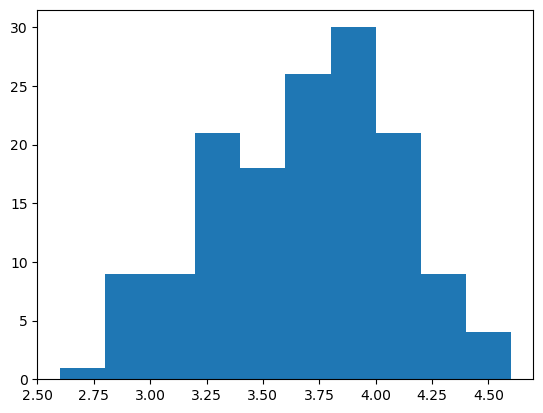

In [52]:
plt.hist(df["rate"],bins=10)
plt.show()

# 4. Zomato has observed that most couples order most of their food online. What is their average spending on each order?

In [55]:
df.head(1)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet


In [57]:
df.groupby("online_order")["approx_cost(for two people)"].mean()

online_order
No     358.888889
Yes    510.344828
Name: approx_cost(for two people), dtype: float64

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

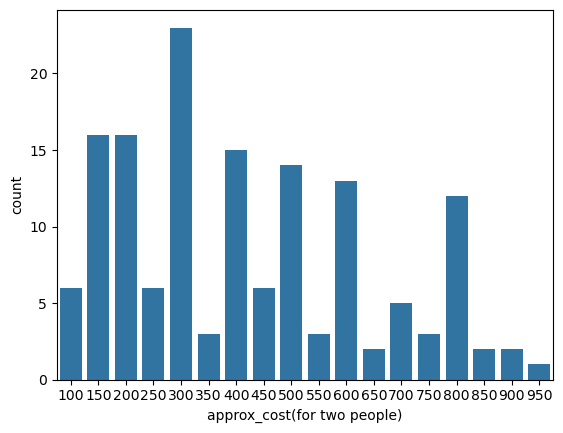

In [59]:
sns.countplot(x="approx_cost(for two people)",data=df)

# 5.Which mode (online or offline) has received the maximum rating?

In [61]:
df.head(1)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet


In [63]:
df.groupby("online_order")["rate"].sum()

online_order
No     313.9
Yes    223.8
Name: rate, dtype: float64

<Axes: xlabel='online_order', ylabel='rate'>

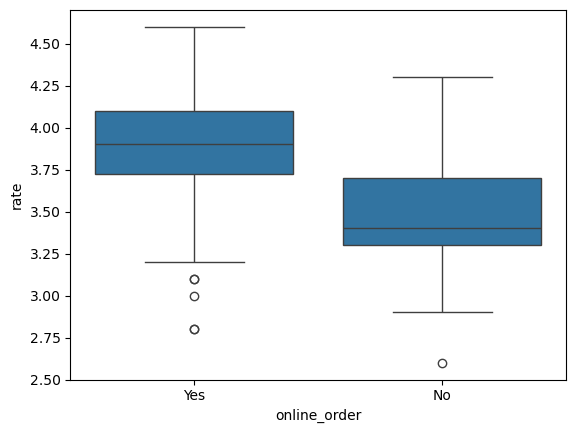

In [64]:
sns.boxplot(data=df,x="online_order",y="rate")

# 6. Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?

In [65]:
df.head(1)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet


In [66]:
df["listed_in(type)"].unique()

array(['Buffet', 'Cafes', 'other', 'Dining'], dtype=object)

In [70]:
pivot_table = df.pivot_table(index="listed_in(type)", columns = "online_order", aggfunc="size",fill_value=0)

In [71]:
pivot_table

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


<Axes: xlabel='online_order', ylabel='listed_in(type)'>

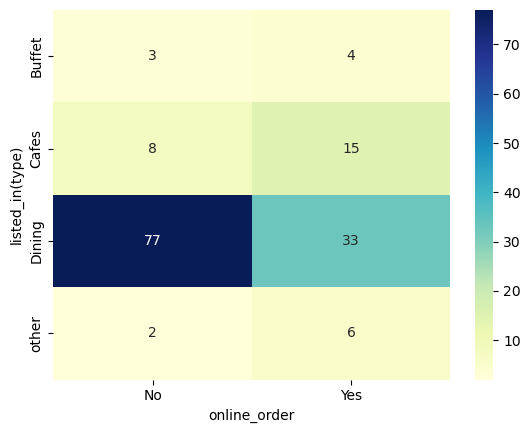

In [73]:
sns.heatmap(pivot_table,annot=True, cmap ="YlGnBu",fmt="d")